In [2]:
# Importing Libraries
import numpy as np
import numpy.linalg as la
import scipy.optimize as sopt
import matplotlib.pyplot as plt
#from time import process_time


In [3]:
from mpl_toolkits.mplot3d import axes3d


In [4]:
# the objective function
def f(x):
        return 0.5*x[0]**2 + 2.5*x[1]**2


In [5]:
# gradient of the objective function
def df(x):
        return np.array ([x[0], 5*x[1]])


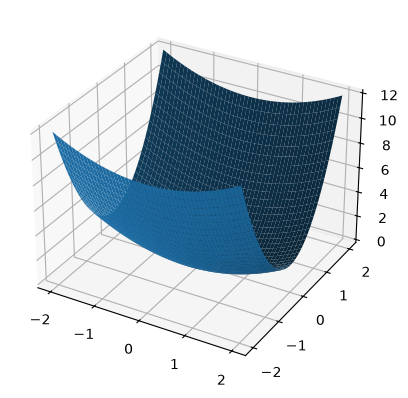

In [6]:
fig = plt.figure()
ax = plt.axes(projection = '3d')

xmesh, ymesh = np.mgrid[-2:2:50j,-2:2:50j]
fmesh = f(np.array([xmesh, ymesh]))
ax.plot_surface(xmesh, ymesh, fmesh)
plt.show()

In [7]:
tol = 1e-8
iteration = 200
# initial guess
y0 = np.array ([1.1, 2.2])

#print(la.norm(pk))
i = 0
#for i in range(iteration):
y = [np.array(y0)] 

number of iteration to satisfy the Wolfe Condition is: 0
the 1 th iterate is: [1.01044665 1.30446653]
number of iteration to satisfy the Wolfe Condition is: 0
the 2 th iterate is: [0.87266136 0.41507617]
number of iteration to satisfy the Wolfe Condition is: 0
the 3 th iterate is: [ 0.52381186 -0.41456474]
number of iteration to satisfy the Wolfe Condition is: 1
the 4 th iterate is: [0.3253597  0.37074841]
number of iteration to satisfy the Wolfe Condition is: 2
the 5 th iterate is: [ 0.1993356  -0.34727591]
number of iteration to satisfy the Wolfe Condition is: 3
the 6 th iterate is: [0.12450708 0.30454301]
number of iteration to satisfy the Wolfe Condition is: 4
the 7 th iterate is: [ 0.07638537 -0.2839829 ]
number of iteration to satisfy the Wolfe Condition is: 5
the 8 th iterate is: [0.04783738 0.24669078]
number of iteration to satisfy the Wolfe Condition is: 6
the 9 th iterate is: [ 0.0293014  -0.23124681]
number of iteration to satisfy the Wolfe Condition is: 7
the 10 th iterate

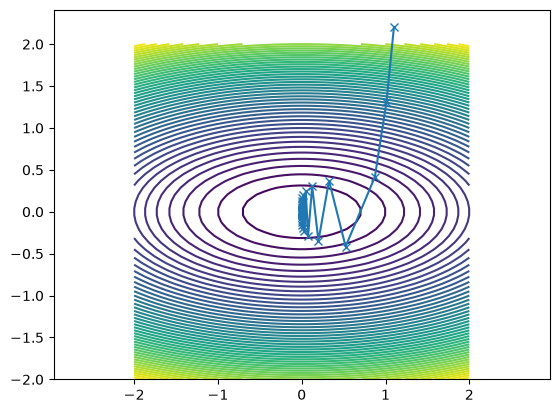

In [8]:
while la.norm(df(y[i])) > tol :
# descent direction = steepest descent direction
        pk = -df(y[i]) / la.norm(df(y[i])) 
# Backtracking algorithm
        rho = 0.9 # the contraction factor
        alpha = 0.9 # the first guess for step length
        c = 1e-4
        j = 0
        while f(y[i] + alpha * pk) > f(y[i]) + c * alpha * np.dot(df(y[i]), pk) :
                alpha = alpha * rho
                j +=1

        alphak = alpha
        y1 = y[i] + alpha * pk
        y.append(y1)
        i += 1
        print('number of iteration to satisfy the Wolfe Condition is:', j)
        print('the',i,'th iterate is:', y[i])

print('gradient of the solution = ', df(y[i]))
print('the value at solution = ', f(y[i]))
print('number of iterations taken =', i)

plt.axis("equal")
plt.contour(xmesh, ymesh, fmesh, 50)
it_array = np.array(y)
plt.plot(it_array.T[0], it_array.T[1], "x-")
plt.show()